<a href="https://colab.research.google.com/github/paulinaeb/IDaSec-project/blob/exp3/after_evasion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone --branch exp4 https://github.com/paulinaeb/IDaSec-project.git

Cloning into 'IDaSec-project'...
remote: Enumerating objects: 403, done.
remote: Counting objects: 100% (237/237), done.
remote: Compressing objects: 100% (195/195), done.
remote: Total 403 (delta 122), reused 138 (delta 34), pack-reused 166 (from 1)
Receiving objects: 100% (403/403), 41.46 MiB | 4.81 MiB/s, done.
Resolving deltas: 100% (182/182), done.
Updating files: 100% (57/57), done.


In [ ]:
!pip uninstall -y torch torchtext

Found existing installation: torch 2.6.0+cu124
Uninstalling torch-2.6.0+cu124:
  Successfully uninstalled torch-2.6.0+cu124


In [ ]:
# !pip install --upgrade torchtext
# !pip install --upgrade torch
!pip install torch==2.2.0 torchtext==0.17.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9

In [ ]:
import warnings as wrn

wrn.filterwarnings('ignore')

import os
import numpy
import pandas as pd
import torch
import torch
from torch.utils.data import DataLoader, Dataset
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from torch.nn.utils.rnn import pad_sequence
import pickle
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt


## Enron1

In [ ]:
# Path to the dataset folder
dataset_path = "IDaSec-project/dataset/enron1"

# List all subfolders in dataset
subfolders = [f.name for f in os.scandir(dataset_path) if f.is_dir()]
print("available datasets:", subfolders)

enron1_charswap_path = dataset_path + "/charswap"
enron1_homoglyph_path = dataset_path + "/homoglyph"
enron1_spacing_path = dataset_path + "/spacing"

enron1_charswap_files = os.listdir(enron1_charswap_path)
print(f"\nFiles in '{enron1_charswap_path}': {enron1_charswap_files}")

enron1_homoglyph_files = os.listdir(enron1_homoglyph_path)
print(f"\nFiles in '{enron1_homoglyph_path}': {enron1_homoglyph_files}")

enron1_spacing_files = os.listdir(enron1_spacing_path)
print(f"\nFiles in '{enron1_spacing_path}': {enron1_spacing_files}")

available datasets: ['charswap', 'spacing', 'mixed', 'homoglyph']

Files in 'IDaSec-project/dataset/enron1/charswap': ['enron1_test_with_charswap.csv', 'enron1_train_with_charswap.csv', 'enron1_val_with_charswap.csv']

Files in 'IDaSec-project/dataset/enron1/homoglyph': ['enron1_train_homoglyph.csv', 'enron1_test_homoglyph.csv', 'enron1_val_homoglyph.csv']

Files in 'IDaSec-project/dataset/enron1/spacing': ['enron1_test_spacing.csv', 'enron1_train_spacing.csv', 'enron1_val_spacing.csv']



### Enron1-charswap

In [ ]:
enron1_charswap_train = pd.read_csv(enron1_charswap_path + "/enron1_test_with_charswap.csv")
enron1_charswap_test = pd.read_csv(enron1_charswap_path + "/enron1_train_with_charswap.csv")
enron1_charswap_val = pd.read_csv(enron1_charswap_path + "/enron1_val_with_charswap.csv")

In [ ]:
enron1_charswap_train.head()

,email,target,email_charswapped,was_augmented
0,Subject: unify / sitara enhancements i am comp...,ham,Subject: unify / sitara enhancements i am comp...,False
1,Subject: weekend activity dated : june 2 thru ...,ham,Subject: weekend activity dated : june 2 thru ...,False
2,Subject: re : tittletattle secrets dn ' t ie n...,spam,"[""Subject: re: tittletattle secrets dn ' t ie ...",True
3,"Subject: deal id 109475 daren , the above deal...",ham,"Subject: deal id 109475 daren , the above deal...",False
4,Subject: weekend entertainment alpha male plus...,spam,['Subject: wekened etneratinmnet aplha amle pl...,True


### Enron1-homoglyph


In [ ]:
enron1_homoglyph_train = pd.read_csv(enron1_homoglyph_path + "/enron1_train_homoglyph.csv")
enron1_homoglyph_test = pd.read_csv(enron1_homoglyph_path + "/enron1_test_homoglyph.csv")
enron1_homoglyph_val = pd.read_csv(enron1_homoglyph_path + "/enron1_val_homoglyph.csv")

In [ ]:
enron1_homoglyph_train.head()

,email,target,email_homoglyph
0,"Subject: prom dress shopping hi , just wanted ...",ham,"Subject: prom dress shopping hi , just wanted ..."
1,"Subject: hi agaain hello , welcome to pharm la...",spam,"𝕾𝓾bjec𝕥∶ hi aga𝕒in hell𝙤 , welcome to p𝒉𝔞ꭈm la..."
2,Subject: feedback monitor error - meter 984132...,ham,Subject: feedback monitor error - meter 984132...
3,Subject: instructions to remove spyware / adwa...,spam,𝘚ubｊ𝕖ctː instructions to r𝖾move sｐℽware / adwa...
4,Subject: acrobat pro 7 . 0 $ 69 . 95 xp pro op...,spam,Sꭒb𝒋𝙚c𝙩︰ a𝕔roba𝘵 𝗉r𝝄 7 𝅭 0 $ 69 . 95 x𝝔 pro op...


### Enron1-spacing


In [ ]:
enron1_spacing_train = pd.read_csv(enron1_spacing_path + "/enron1_train_spacing.csv")
enron1_spacing_test = pd.read_csv(enron1_spacing_path + "/enron1_test_spacing.csv")
enron1_spacing_val = pd.read_csv(enron1_spacing_path + "/enron1_val_spacing.csv")

In [ ]:
enron1_spacing_train.head()

,email,target,email_spaced
0,"Subject: prom dress shopping hi , just wanted ...",ham,"Subject: prom dress shopping hi , just wanted ..."
1,"Subject: hi agaain hello , welcome to pharm la...",spam,"Subject: hi agaain he llo , w e l c o m e to p..."
2,Subject: feedback monitor error - meter 984132...,ham,Subject: feedback monitor error - meter 984132...
3,Subject: instructions to remove spyware / adwa...,spam,Subject: i n s t r u c t i o n s to r e m o v ...
4,Subject: acrobat pro 7 . 0 $ 69 . 95 xp pro op...,spam,Subject: a c r o b a t p r o 7 . 0 $ 69 . 95 x...


In [ ]:
# enron1_spacing_train.info()

## adversarial

In [ ]:
enron1_light_adversarial_train_path = "IDaSec-project/dataset/enron1/enron1_train_lightadversarial.csv"
enron1_light_adversarial_val_path = "IDaSec-project/dataset/enron1/enron1_val_lightadversarial.csv"
enron1_light_adversarial_test_path = "IDaSec-project/dataset/enron1/enron1_test_lightadversarial.csv"

enron1_light_adversarial_train = pd.read_csv(enron1_light_adversarial_train_path)
enron1_light_adversarial_val = pd.read_csv(enron1_light_adversarial_val_path)
enron1_light_adversarial_test = pd.read_csv(enron1_light_adversarial_test_path)

In [ ]:
enron1_light_adversarial_train.head()

,original,adversarial_light,target
0,"Subject: prom dress shopping hi , just wanted ...","Subject: prom dress shopping hi , just wanted ...",ham
1,"Subject: hi agaain hello , welcome to pharm la...","Subject: hi agaain hello , welcome to pharm la...",spam
2,Subject: feedback monitor error - meter 984132...,Subject: feedback monitor error - meter 984132...,ham
3,Subject: instructions to remove spyware / adwa...,Subject: instructions to remove $pyw@r3 / adwa...,spam
4,Subject: acrobat pro 7 . 0 $ 69 . 95 xp pro op...,Subject: acrobat pr0 7 . 0 $ 69 . 95 xp pro op...,spam


In [ ]:
enron1_light_adversarial_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3196 entries, 0 to 3195
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   original           3196 non-null   object
 1   adversarial_light  3196 non-null   object
 2   target             3196 non-null   object
dtypes: object(3)
memory usage: 75.0+ KB


## Enron1-charswap-fine tuning




### 1. arrange the dataset to have only 2 columns

In [ ]:
# enron1_charswap_train.head()

In [ ]:
# enron1_charswap_test.head()

In [ ]:
# enron1_charswap_val.head()

In [ ]:
# def arrange_dataset(dataset):
#   # 1) delete email column
#   del dataset['email']

#   # 2) delete was_augmented column
#   del dataset['was_augmented']

#   # 3) rename the email_charswapped column to email
#   dataset = dataset.rename(columns={'email_charswapped': 'email'})

#   # 4) reorder the table where email is at the beginning and target next
#   cols = ['email', 'target']
#   dataset = dataset[cols]
#   return dataset

# enron1_charswap_train = arrange_dataset(enron1_charswap_train)
# enron1_charswap_test = arrange_dataset(enron1_charswap_test)
# enron1_charswap_val = arrange_dataset(enron1_charswap_val)

# arrange homoglyph
def arrange_homoglyph_dataset(dataset):
  # 1) delete email column
  del dataset['email']

  # 2) delete was_augmented column
  dataset = dataset.rename(columns={'email_homoglyph': 'email'})

  cols = ['email', 'target']
  dataset = dataset[cols]
  return dataset

# use rearrange homoglyph dataset function
enron1_homoglyph_train = arrange_homoglyph_dataset(enron1_homoglyph_train)
enron1_homoglyph_test = arrange_homoglyph_dataset(enron1_homoglyph_test)
enron1_homoglyph_val = arrange_homoglyph_dataset(enron1_homoglyph_val)

# arrange spacing
def arrange_spacing_dataset(dataset):
  # 1) delete email column
  del dataset['email']

  # 2) delete was_augmented column
  dataset = dataset.rename(columns={'email_spaced': 'email'})
  cols = ['email', 'target']
  dataset = dataset[cols]
  return dataset

# use arrange spacing function
enron1_spacing_train = arrange_spacing_dataset(enron1_spacing_train)
enron1_spacing_test = arrange_spacing_dataset(enron1_spacing_test)
enron1_spacing_val = arrange_spacing_dataset(enron1_spacing_val)

In [ ]:
enron1_spacing_train.head()

,email,target
0,"Subject: prom dress shopping hi , just wanted ...",ham
1,"Subject: hi agaain he llo , w e l c o m e to p...",spam
2,Subject: feedback monitor error - meter 984132...,ham
3,Subject: i n s t r u c t i o n s to r e m o v ...,spam
4,Subject: a c r o b a t p r o 7 . 0 $ 69 . 95 x...,spam


In [ ]:
enron1_charswap_test.head()


,email,target
0,"Subject: prom dress shopping hi , just wanted ...",ham
1,"['Subject: hi agaani ehllo, welcome to pharm l...",spam
2,Subject: feedback monitor error - meter 984132...,ham
3,"[""Subject: instructions to remove spyware / ad...",spam
4,['Subject: carboat pro 7. 0 $ 69. 95 xp pro op...,spam


In [ ]:
enron1_charswap_val.head()

,email,target
0,Subject: union carbide - seadrift hpl meter # ...,ham
1,"[""Subject: best choice rx - free online rpecsr...",spam
2,Subject: new nat gas delivery location pursuan...,ham
3,Subject: weekend activity dated : june 2 thru ...,ham
4,Subject: meter 5593 daren - canyou get a deal ...,ham


### 2. add the label column

In [ ]:
label_map = {"ham": 0, "spam": 1}

# define a function to add the label column to dataset
def add_label_column(dataset, label_map):
  dataset['label'] = dataset['target'].map(label_map)
  return dataset

############################ Enron1 Charswap ######################################
enron1_charswap_train = add_label_column(enron1_charswap_train, label_map)
enron1_charswap_test = add_label_column(enron1_charswap_test, label_map)
enron1_charswap_val = add_label_column(enron1_charswap_val, label_map)

############################ Enron1 homoglyph ######################################
enron1_homoglyph_train = add_label_column(enron1_homoglyph_train, label_map)
enron1_homoglyph_test = add_label_column(enron1_homoglyph_test, label_map)
enron1_homoglyph_val = add_label_column(enron1_homoglyph_val, label_map)

############################ Enron1 spacing ######################################
enron1_spacing_train = add_label_column(enron1_spacing_train, label_map)
enron1_spacing_test = add_label_column(enron1_spacing_test, label_map)
enron1_spacing_val = add_label_column(enron1_spacing_val, label_map)


### 3. setup tokenizer and vocabulary

In [ ]:
# use tokenizer from SpaCy
tokenizer = get_tokenizer("spacy", language="en_core_web_sm")

# define the function only in the email column
def yield_tokens(data_iter):
  for index, row in data_iter.iterrows():
        yield tokenizer(row['email'])

# enron1_charswap_vocab
enron1_charswap_vocab = build_vocab_from_iterator(yield_tokens(enron1_charswap_train), specials=["<unk>", "<pad>"])
enron1_charswap_vocab.set_default_index(enron1_charswap_vocab["<unk>"])

# enron1_homoglyph_vocab
enron1_homoglyph_vocab = build_vocab_from_iterator(yield_tokens(enron1_homoglyph_train), specials=["<unk>", "<pad>"])
enron1_homoglyph_vocab.set_default_index(enron1_homoglyph_vocab["<unk>"])

# enron1_spacing_vocab
enron1_spacing_vocab = build_vocab_from_iterator(yield_tokens(enron1_spacing_train), specials=["<unk>", "<pad>"])
enron1_spacing_vocab.set_default_index(enron1_spacing_vocab["<unk>"])


### 4. Create datasets and dataloaders

In [ ]:
class TextDataset(Dataset):
    def __init__(self, data, vocab, tokenizer, label_map):
        self.data = data
        self.vocab = vocab
        self.tokenizer = tokenizer
        self.label_map = label_map

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data.iloc[idx]  # <-- change this line
        text = torch.tensor(self.vocab(self.tokenizer(item['email'])), dtype=torch.long)
        label = torch.tensor(self.label_map[item['target']], dtype=torch.float)
        return text, label


In [ ]:
def collate_batch(batch):
    texts, labels = zip(*batch)
    lengths = torch.tensor([len(t) for t in texts])
    padded_texts = pad_sequence(texts, batch_first=True, padding_value=vocab["<pad>"])
    labels = torch.stack(labels)
    return padded_texts, lengths, labels


In [ ]:
BATCH_SIZE = 64
label_map = {"ham": 0, "spam": 1}

# define a function to generate data loader
def generate_data_loader(train_dataset,val_dataset,test_dataset, vocab, tokenizer = tokenizer, label_map = label_map, batch_size = BATCH_SIZE):
  # generate textdataset objects
  train_text_dataset = TextDataset(train_dataset, vocab, tokenizer, label_map)
  val_text_dataset = TextDataset(val_dataset, vocab, tokenizer, label_map)
  test_text_dataset = TextDataset(test_dataset, vocab, tokenizer, label_map)
  # generate dataloader objects
  train_dataloader = DataLoader(train_text_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_batch)
  val_dataloader = DataLoader(val_text_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_batch)
  test_dataloader = DataLoader(test_text_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_batch)
  return train_dataloader, val_dataloader, test_dataloader

# use generate_data_loader function
train_loader_enron1_charswap, val_loader_enron1_charswap, test_loader_enron1_charswap = generate_data_loader(enron1_charswap_train,enron1_charswap_val,enron1_charswap_test, enron1_charswap_vocab)
train_loader_enron1_homoglyph, val_loader_enron1_homoglyph, test_loader_enron1_homoglyph = generate_data_loader(enron1_homoglyph_train,enron1_homoglyph_val,enron1_homoglyph_test, enron1_homoglyph_vocab)
train_loader_enron1_spacing, val_loader_enron1_spacing, test_loader_enron1_spacing = generate_data_loader(enron1_spacing_train,enron1_spacing_val,enron1_spacing_test, enron1_spacing_vocab)


### 5. calling enron1 model

In [ ]:
import torch.nn as nn

class LSTMNet(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, bidirectional, dropout):
        super(LSTMNet, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.lstm = nn.LSTM(embedding_dim,
                            hidden_dim,
                            num_layers=n_layers,
                            bidirectional=bidirectional,
                            dropout=dropout,
                            batch_first=True)

        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, text, text_lengths):
        embedded = self.embedding(text)

        packed_embedded = nn.utils.rnn.pack_padded_sequence(
            embedded, text_lengths.cpu(), batch_first=True, enforce_sorted=False
        )

        packed_output, (hidden_state, cell_state) = self.lstm(packed_embedded)

        hidden = torch.cat((hidden_state[-2, :, :], hidden_state[-1, :, :]), dim=1)

        logits = self.fc(hidden)

        return logits  # raw logits (no sigmoid)


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

EMBEDDING_DIM = 100
NUM_HIDDEN_NODES = 64
NUM_OUTPUT_NODES = 1
NUM_LAYERS = 2
BIDIRECTION = True
DROPOUT = 0.2

SIZE_OF_charswap_VOCAB = len(enron1_charswap_vocab)
SIZE_OF_homoglyph_VOCAB = len(enron1_homoglyph_vocab)
SIZE_OF_spacing_VOCAB = len(enron1_spacing_vocab)

# define get_model function
def get_model(vocab_size, weights_path):
  model = LSTMNet(vocab_size,
                EMBEDDING_DIM,
                NUM_HIDDEN_NODES,
                NUM_OUTPUT_NODES,
                NUM_LAYERS,
                BIDIRECTION,
                DROPOUT
               )
  checkpoint = torch.load(weights_path)

  # Only load matching keys
  model_dict = model.state_dict()

  # filter out unmatched layers
  pretrained_dict = {k: v for k, v in checkpoint.items() if k in model_dict and model_dict[k].shape == v.shape}

  model_dict.update(pretrained_dict)
  model.load_state_dict(model_dict)
  return model

# use get_model function
enron1_charswap_model = get_model(SIZE_OF_charswap_VOCAB,"enron1_model_weights.pth").to(device)
enron1_homoglyph_model = get_model(SIZE_OF_homoglyph_VOCAB,"enron1_model_weights.pth").to(device)
enron1_spacing_model = get_model(SIZE_OF_spacing_VOCAB,"enron1_model_weights.pth").to(device)



In [ ]:
import numpy as np
import torch.nn as nn
import torch.optim as optim

# define get_optimizer function
def get_optimizer(model, learning_rate):
  optimizer = optim.Adam(model.parameters(), lr=learning_rate)
  return optimizer

# use get_optimizer function
enron1_charswap_optimizer = get_optimizer(enron1_charswap_model, 1e-4)
enron1_homoglyph_optimizer = get_optimizer(enron1_homoglyph_model, 1e-4)
enron1_spacing_optimizer = get_optimizer(enron1_spacing_model, 1e-4)

# define get_criterion function
def get_criterion(train_dataset):

  # enron1 criterion
  train_labels = train_dataset['label'].values
  train_pos_weight = torch.tensor([np.sum(train_labels == 0) / np.sum(train_labels == 1)], dtype=torch.float).to(device)

  # Binary Cross Entropy (for binary classification)
  criterion = nn.BCEWithLogitsLoss(pos_weight=train_pos_weight).to(device)
  return criterion

# use get_criterion function
enron1_charswap_criterion = get_criterion(enron1_charswap_train)
enron1_homoglyph_criterion = get_criterion(enron1_homoglyph_train)
enron1_spacing_criterion = get_criterion(enron1_spacing_train)





In [ ]:
# def binary_accuracy(preds, y):
#     # round predictions to 0 or 1
#     rounded_preds = torch.round(preds)
#     correct = (rounded_preds == y).float()
#     acc = correct.sum() / len(correct)
#     return acc

def binary_accuracy(preds, y):
    # Apply sigmoid to get probabilities
    probs = torch.sigmoid(preds)
    rounded_preds = torch.round(probs)
    correct = (rounded_preds == y).float()
    acc = correct.sum() / len(correct)
    return acc


In [ ]:
def train(model, dataloader, optimizer, criterion):
    epoch_loss = 0.0
    epoch_acc = 0.0

    model.train()

    for text, text_lengths, labels in dataloader:
        text = text.to(device)
        text_lengths = text_lengths.to(device)
        labels = labels.to(device).float()

        optimizer.zero_grad()

        predictions = model(text, text_lengths).squeeze(1)

        loss = criterion(predictions, labels)
        acc = binary_accuracy(predictions, labels)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += acc.item()

    return epoch_loss / len(dataloader), epoch_acc / len(dataloader)


In [ ]:
def evaluate(model, dataloader, criterion):
    epoch_loss = 0.0
    epoch_acc = 0.0

    model.eval()

    with torch.no_grad():
        for text, text_lengths, labels in dataloader:
            text = text.to(device)
            text_lengths = text_lengths.to(device)
            labels = labels.to(device).float()

            predictions = model(text, text_lengths).squeeze(1)

            loss = criterion(predictions, labels)
            acc = binary_accuracy(predictions, labels)

            epoch_loss += loss.item()
            epoch_acc += acc.item()

    return epoch_loss / len(dataloader), epoch_acc / len(dataloader)


In [ ]:
EPOCH_NUMBER = 20

# train and evaluate and save model function
def train_evaluate_save_loop(model, train_loader, val_loader, optimizer, criterion,dataset_name,epochs=EPOCH_NUMBER,patience=3):
  best_val_loss = float("inf")
  epochs_no_improve = 0
  train_loss_history = []
  val_loss_history = []
  for epoch in range(1, EPOCH_NUMBER + 1):
      train_loss, train_acc = train(model, train_loader, optimizer, criterion)
      valid_loss, valid_acc = evaluate(model, val_loader, criterion)

      train_loss_history.append(train_loss)
      val_loss_history.append(valid_loss)
      print(f"Epoch: {epoch}")
      print(f'Train Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
      print(f'Val. Loss: {valid_loss:.3f} |  Val. Acc: {valid_acc*100:.2f}%')
      print()
      if valid_loss < best_val_loss:
          best_val_loss = valid_loss
          torch.save(model.state_dict(), f"{dataset_name}_model_weights.pth")
          epochs_no_improve = 0
      else:
          epochs_no_improve += 1

      if epochs_no_improve >= patience:
          print("Early stopping triggered.")
          break
  with open(f"{dataset_name}_loss_history.pkl", "wb") as f:
    pickle.dump((train_loss_history, val_loss_history), f)
  return train_loss_history, val_loss_history

# plot losses function
def plot_losses(train_losses, val_losses):
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Losses")
    plt.legend()
    plt.grid(True)
    plt.show()

# review model performance function
def test_model(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for text, lengths, labels in data_loader:
            text, lengths, labels = text.to(device), lengths.to(device), labels.to(device)
            outputs = torch.sigmoid(model(text, lengths)).squeeze()  # <- sigmoid here
            preds = torch.round(outputs)

            all_preds.extend(preds.tolist())
            all_labels.extend(labels.tolist())

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    report = classification_report(all_labels, all_preds, zero_division=0)
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print("\nClassification Report:\n", report)


Epoch: 1
Train Loss: 1.161 | Train Acc: 51.82%
Val. Loss: 1.298 |  Val. Acc: 53.96%

Epoch: 2
Train Loss: 0.833 | Train Acc: 64.71%
Val. Loss: 1.005 |  Val. Acc: 65.78%

Epoch: 3
Train Loss: 0.660 | Train Acc: 72.51%
Val. Loss: 0.826 |  Val. Acc: 73.84%

Epoch: 4
Train Loss: 0.549 | Train Acc: 81.85%
Val. Loss: 0.768 |  Val. Acc: 79.66%

Epoch: 5
Train Loss: 0.451 | Train Acc: 87.68%
Val. Loss: 0.661 |  Val. Acc: 82.66%

Epoch: 6
Train Loss: 0.377 | Train Acc: 91.18%
Val. Loss: 0.569 |  Val. Acc: 85.91%

Epoch: 7
Train Loss: 0.305 | Train Acc: 93.33%
Val. Loss: 0.515 |  Val. Acc: 87.97%

Epoch: 8
Train Loss: 0.256 | Train Acc: 95.09%
Val. Loss: 0.445 |  Val. Acc: 89.90%

Epoch: 9
Train Loss: 0.211 | Train Acc: 96.23%
Val. Loss: 0.367 |  Val. Acc: 91.70%

Epoch: 10
Train Loss: 0.176 | Train Acc: 97.46%
Val. Loss: 0.321 |  Val. Acc: 93.38%

Epoch: 11
Train Loss: 0.146 | Train Acc: 98.24%
Val. Loss: 0.272 |  Val. Acc: 94.46%

Epoch: 12
Train Loss: 0.122 | Train Acc: 98.37%
Val. Loss: 0.23

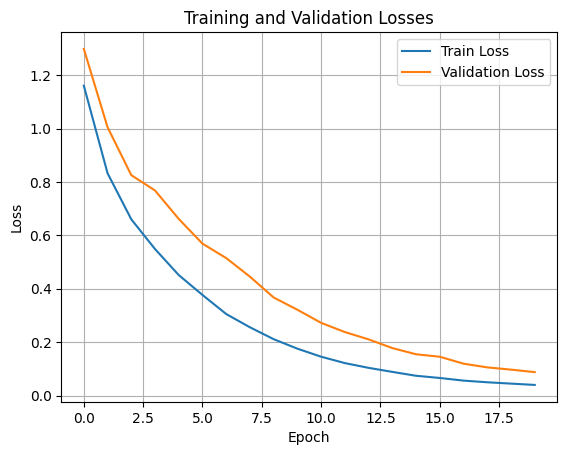

Accuracy: 0.9897
Precision: 0.9798
Recall: 0.9850
F1-score: 0.9824

Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      2260
         1.0       0.98      0.99      0.98       936

    accuracy                           0.99      3196
   macro avg       0.99      0.99      0.99      3196
weighted avg       0.99      0.99      0.99      3196



In [ ]:

# train and evaluate the model on enron1
enron1_charswap_train_loss_history,enron1_charswap_valid_loss_history = train_evaluate_save_loop(enron1_charswap_model, train_loader_enron1_charswap, val_loader_enron1_charswap, enron1_charswap_optimizer, enron1_charswap_criterion,dataset_name='enron1_charswap')

# plot the losses
plot_losses(enron1_charswap_train_loss_history, enron1_charswap_valid_loss_history)

# test the model
test_model(enron1_charswap_model, test_loader_enron1_charswap)



Epoch: 1
Train Loss: 0.690 | Train Acc: 73.61%
Val. Loss: 0.331 |  Val. Acc: 89.03%

Epoch: 2
Train Loss: 0.260 | Train Acc: 92.15%
Val. Loss: 0.127 |  Val. Acc: 96.50%

Epoch: 3
Train Loss: 0.135 | Train Acc: 96.59%
Val. Loss: 0.103 |  Val. Acc: 96.99%

Epoch: 4
Train Loss: 0.085 | Train Acc: 97.94%
Val. Loss: 0.066 |  Val. Acc: 98.07%

Epoch: 5
Train Loss: 0.059 | Train Acc: 98.66%
Val. Loss: 0.053 |  Val. Acc: 98.55%

Epoch: 6
Train Loss: 0.049 | Train Acc: 99.00%
Val. Loss: 0.041 |  Val. Acc: 99.40%

Epoch: 7
Train Loss: 0.039 | Train Acc: 99.34%
Val. Loss: 0.036 |  Val. Acc: 99.40%

Epoch: 8
Train Loss: 0.034 | Train Acc: 99.47%
Val. Loss: 0.030 |  Val. Acc: 99.64%

Epoch: 9
Train Loss: 0.027 | Train Acc: 99.56%
Val. Loss: 0.021 |  Val. Acc: 99.76%

Epoch: 10
Train Loss: 0.027 | Train Acc: 99.78%
Val. Loss: 0.021 |  Val. Acc: 99.76%

Epoch: 11
Train Loss: 0.021 | Train Acc: 99.72%
Val. Loss: 0.019 |  Val. Acc: 99.76%

Epoch: 12
Train Loss: 0.017 | Train Acc: 99.88%
Val. Loss: 0.01

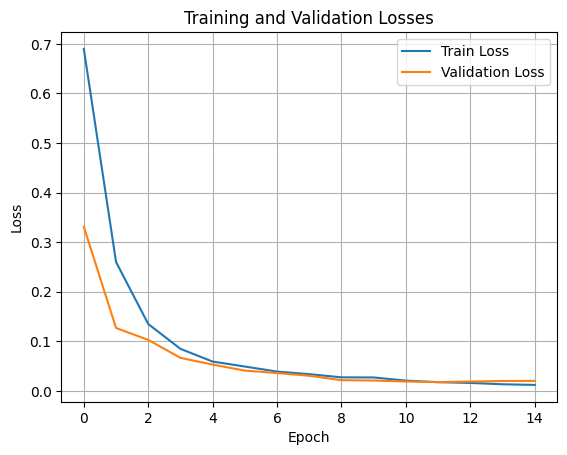

Accuracy: 0.9970
Precision: 0.9966
Recall: 0.9932
F1-score: 0.9949

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       706
         1.0       1.00      0.99      0.99       293

    accuracy                           1.00       999
   macro avg       1.00      1.00      1.00       999
weighted avg       1.00      1.00      1.00       999



In [ ]:

# do the same for enron1_homoglyph
enron1_homoglyph_train_loss_history,enron1_homoglyph_valid_loss_history = train_evaluate_save_loop(enron1_homoglyph_model, train_loader_enron1_homoglyph, val_loader_enron1_homoglyph, enron1_homoglyph_optimizer, enron1_homoglyph_criterion,dataset_name='enron1_homoglyph')

# plot the losses
plot_losses(enron1_homoglyph_train_loss_history, enron1_homoglyph_valid_loss_history)

# test the model
test_model(enron1_homoglyph_model, test_loader_enron1_homoglyph)


Epoch: 1
Train Loss: 1.079 | Train Acc: 48.06%
Val. Loss: 0.754 |  Val. Acc: 74.56%

Epoch: 2
Train Loss: 0.551 | Train Acc: 83.68%
Val. Loss: 0.384 |  Val. Acc: 90.48%

Epoch: 3
Train Loss: 0.298 | Train Acc: 92.93%
Val. Loss: 0.268 |  Val. Acc: 94.46%

Epoch: 4
Train Loss: 0.199 | Train Acc: 95.75%
Val. Loss: 0.218 |  Val. Acc: 95.55%

Epoch: 5
Train Loss: 0.152 | Train Acc: 97.03%
Val. Loss: 0.208 |  Val. Acc: 95.67%

Epoch: 6
Train Loss: 0.117 | Train Acc: 97.43%
Val. Loss: 0.186 |  Val. Acc: 96.63%

Epoch: 7
Train Loss: 0.099 | Train Acc: 97.81%
Val. Loss: 0.180 |  Val. Acc: 96.39%

Epoch: 8
Train Loss: 0.084 | Train Acc: 98.22%
Val. Loss: 0.166 |  Val. Acc: 96.51%

Epoch: 9
Train Loss: 0.074 | Train Acc: 98.40%
Val. Loss: 0.149 |  Val. Acc: 97.00%

Epoch: 10
Train Loss: 0.062 | Train Acc: 98.50%
Val. Loss: 0.129 |  Val. Acc: 97.24%

Epoch: 11
Train Loss: 0.055 | Train Acc: 98.65%
Val. Loss: 0.131 |  Val. Acc: 97.24%

Epoch: 12
Train Loss: 0.046 | Train Acc: 98.97%
Val. Loss: 0.13

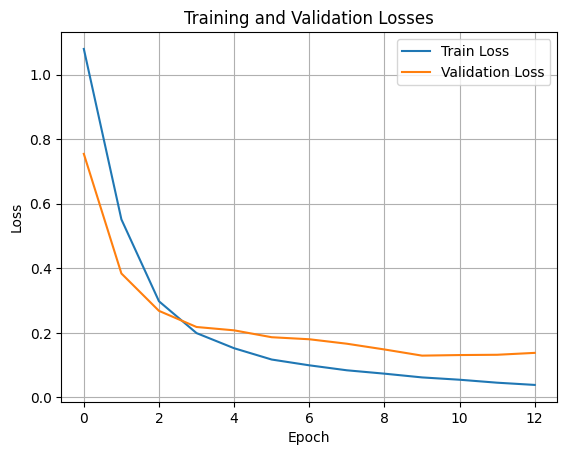

Accuracy: 0.9670
Precision: 0.9710
Recall: 0.9147
F1-score: 0.9420

Classification Report:
               precision    recall  f1-score   support

         0.0       0.97      0.99      0.98       706
         1.0       0.97      0.91      0.94       293

    accuracy                           0.97       999
   macro avg       0.97      0.95      0.96       999
weighted avg       0.97      0.97      0.97       999



In [ ]:
#  do the same for spacing
enron1_spacing_train_loss_history,enron1_spacing_valid_loss_history = train_evaluate_save_loop(enron1_spacing_model, train_loader_enron1_spacing, val_loader_enron1_spacing, enron1_spacing_optimizer, enron1_spacing_criterion,dataset_name='enron1_spacing')

# plot the losses
plot_losses(enron1_spacing_train_loss_history, enron1_spacing_valid_loss_history)

# test the model
test_model(enron1_spacing_model, test_loader_enron1_spacing)
